

# Project : Customer Churn Prediction with FastAPI (Model Deployment)

Train a churn model, save it, wrap it in a FastAPI service with input validation, run the API inside Colab, test it, measure latency, and create Docker files for real deployment.

## What this notebook does
- Trains a scikit-learn pipeline on the IBM Telco churn data (made-up fallback if download fails)
- Saves the model with joblib together with model info (training time, library version, calibration check)
- Writes a FastAPI app (`app.py`) with /health, /model-info, /predict and /predict_batch
- Validates inputs with Pydantic (bad input returns a clear 422 error)
- Runs the server in the background and calls it with requests
- Runs 11 automated checks (good input, bad input, wrong key, oversized batch, inconsistent values) and measures speed (p50 / p95 latency)
- Writes `requirements.txt` and `Dockerfile` so the API can be deployed anywhere

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again
4. The API runs inside Colab only while the notebook is running. The Docker files at the end are for real deployment on your own machine or a cloud service.

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy scikit-learn joblib fastapi uvicorn requests pydantic

## Step 2: Load the data

In [2]:
import os, time, json, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
np.random.seed(11)

def make_telco(n=5000):
    tenure = np.random.randint(0, 73, n)
    contract = np.random.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.22, 0.23])
    internet = np.random.choice(["DSL", "Fiber optic", "No"], n, p=[0.35, 0.45, 0.2])
    monthly = np.round(np.where(internet == "Fiber optic", np.random.normal(90, 15, n), np.where(internet == "DSL", np.random.normal(58, 12, n), np.random.normal(22, 5, n))), 2)
    df = pd.DataFrame({
        "SeniorCitizen": np.random.choice([0, 1], n, p=[0.84, 0.16]),
        "tenure": tenure, "InternetService": internet, "Contract": contract,
        "OnlineSecurity": np.where(internet == "No", "No internet service", np.random.choice(["Yes", "No"], n)),
        "TechSupport": np.where(internet == "No", "No internet service", np.random.choice(["Yes", "No"], n)),
        "PaperlessBilling": np.random.choice(["Yes", "No"], n, p=[0.6, 0.4]),
        "PaymentMethod": np.random.choice(["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"], n),
        "MonthlyCharges": monthly})
    df["TotalCharges"] = (df["tenure"] * df["MonthlyCharges"]).round(2)
    score = (-0.6 + (df["Contract"] == "Month-to-month") * 1.3 - (df["Contract"] == "Two year") * 1.2 - df["tenure"] * 0.03
             + (df["InternetService"] == "Fiber optic") * 0.7 + (df["TechSupport"] == "No") * 0.5 + (df["PaymentMethod"] == "Electronic check") * 0.5)
    df["Churn"] = np.where(np.random.rand(n) < 1 / (1 + np.exp(-score)), "Yes", "No")
    return df

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
try:
    df = pd.read_csv(url)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
    print("Real IBM Telco data loaded")
except Exception as e:
    print("Download failed, using made-up data:", str(e)[:60])
    df = make_telco()

features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "InternetService",
            "OnlineSecurity", "TechSupport", "PaperlessBilling", "PaymentMethod"]
X = df[features]
y = (df["Churn"] == "Yes").astype(int)
print(X.shape, "churn rate:", round(y.mean() * 100, 1), "%")
X.head()

Real IBM Telco data loaded
(7043, 10) churn rate: 26.5 %


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaperlessBilling,PaymentMethod
0,0,1,29.85,29.85,Month-to-month,DSL,No,No,Yes,Electronic check
1,0,34,56.95,1889.50,One year,DSL,Yes,No,No,Mailed check
2,0,2,53.85,108.15,Month-to-month,DSL,Yes,No,Yes,Mailed check
3,0,45,42.30,1840.75,One year,DSL,Yes,Yes,No,Bank transfer (automatic)
4,0,2,70.70,151.65,Month-to-month,Fiber optic,No,No,Yes,Electronic check


## Step 3: Train the model pipeline
The pipeline includes the encoding step, so the API can accept raw values like `Month-to-month`.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import joblib

cat_cols = ["Contract", "InternetService", "OnlineSecurity", "TechSupport", "PaperlessBilling", "PaymentMethod"]
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)], remainder="passthrough")
pipe = Pipeline([("prep", prep), ("model", GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipe.fit(X_train, y_train)
auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
print("Test AUC:", round(auc, 3))
test_prob = pipe.predict_proba(X_test)[:, 1]
print("Average predicted churn on test:", round(test_prob.mean() * 100, 1), "% vs actual", round(y_test.mean() * 100, 1), "%")
import sklearn, datetime

allowed = {c: sorted(X[c].unique().tolist()) for c in cat_cols}
info = {"model": "GradientBoostingClassifier", "version": "1.0", "auc": round(auc, 3), "features": features,
        "trained_at": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"), "sklearn_version": sklearn.__version__,
        "risk_labels": "Low under 0.3, Medium 0.3 to 0.6, High 0.6 and above (chosen by hand, not tuned)",
        "allowed_values": allowed, "trained_rows": int(len(X_train))}
joblib.dump(pipe, "churn_model.joblib")
json.dump(info, open("model_info.json", "w"), indent=2)
print("Saved churn_model.joblib and model_info.json")
print(json.dumps(allowed, indent=2))

Test AUC: 0.84
Average predicted churn on test: 26.3 % vs actual 26.5 %
Saved churn_model.joblib and model_info.json
{
  "Contract": [
    "Month-to-month",
    "One year",
    "Two year"
  ],
  "InternetService": [
    "DSL",
    "Fiber optic",
    "No"
  ],
  "OnlineSecurity": [
    "No",
    "No internet service",
    "Yes"
  ],
  "TechSupport": [
    "No",
    "No internet service",
    "Yes"
  ],
  "PaperlessBilling": [
    "No",
    "Yes"
  ],
  "PaymentMethod": [
    "Bank transfer (automatic)",
    "Credit card (automatic)",
    "Electronic check",
    "Mailed check"
  ]
}


## Step 4: Write the FastAPI app
This cell writes a file called `app.py`. The API key check is a simple example of protecting an endpoint.

In [4]:
app_code = """
import json, time, os
from collections import deque
import joblib
import pandas as pd
from typing import List, Literal
from fastapi import FastAPI, Header, HTTPException
from pydantic import BaseModel, Field

model = joblib.load("churn_model.joblib")
info = json.load(open("model_info.json"))
API_KEY = os.environ.get("API_KEY", "demo-key-123")

app = FastAPI(title="Churn Prediction API", version=info["version"])
request_log = deque(maxlen=1000)


def to_dict(model_obj):
    if hasattr(model_obj, "model_dump"):
        return model_obj.model_dump()
    return model_obj.dict()


def check_consistent(c):
    if c.TotalCharges > (c.tenure + 1) * c.MonthlyCharges * 2:
        raise HTTPException(status_code=422, detail="TotalCharges is not consistent with tenure and MonthlyCharges")


class Customer(BaseModel):
    SeniorCitizen: int = Field(..., ge=0, le=1)
    tenure: int = Field(..., ge=0, le=100)
    MonthlyCharges: float = Field(..., gt=0, lt=1000)
    TotalCharges: float = Field(..., ge=0)
    Contract: Literal[CONTRACT_VALUES]
    InternetService: Literal[INTERNET_VALUES]
    OnlineSecurity: Literal[SECURITY_VALUES]
    TechSupport: Literal[SUPPORT_VALUES]
    PaperlessBilling: Literal[PAPERLESS_VALUES]
    PaymentMethod: Literal[PAYMENT_VALUES]


def risk_label(p):
    if p >= 0.6:
        return "High"
    if p >= 0.3:
        return "Medium"
    return "Low"


def check_key(key):
    if key != API_KEY:
        raise HTTPException(status_code=401, detail="Invalid or missing x-api-key header")


@app.get("/health")
def health():
    return {"status": "ok"}


@app.get("/model-info")
def model_info():
    return info


@app.post("/predict")
def predict(customer: Customer, x_api_key: str = Header(default=None)):
    check_key(x_api_key)
    start = time.time()
    check_consistent(customer)
    row = pd.DataFrame([to_dict(customer)])
    prob = float(model.predict_proba(row)[0, 1])
    ms = round((time.time() - start) * 1000, 2)
    request_log.append({"prob": prob, "ms": ms})
    return {"churn_probability": round(prob, 4), "risk": risk_label(prob), "latency_ms": ms}


@app.post("/predict_batch")
def predict_batch(customers: List[Customer], x_api_key: str = Header(default=None)):
    check_key(x_api_key)
    if len(customers) > 1000:
        raise HTTPException(status_code=413, detail="Max 1000 customers per request")
    for c in customers:
        check_consistent(c)
    rows = pd.DataFrame([to_dict(c) for c in customers])
    probs = model.predict_proba(rows)[:, 1]
    return [{"churn_probability": round(float(p), 4), "risk": risk_label(float(p))} for p in probs]


@app.get("/stats")
def stats():
    n = len(request_log)
    avg = sum(r["ms"] for r in request_log) / n if n > 0 else 0
    return {"requests_served": n, "avg_latency_ms": round(avg, 2)}
"""

def as_literal(values):
    return ", ".join(repr(v) for v in values)

app_code = app_code.replace("CONTRACT_VALUES", as_literal(allowed["Contract"]))
app_code = app_code.replace("INTERNET_VALUES", as_literal(allowed["InternetService"]))
app_code = app_code.replace("SECURITY_VALUES", as_literal(allowed["OnlineSecurity"]))
app_code = app_code.replace("SUPPORT_VALUES", as_literal(allowed["TechSupport"]))
app_code = app_code.replace("PAPERLESS_VALUES", as_literal(allowed["PaperlessBilling"]))
app_code = app_code.replace("PAYMENT_VALUES", as_literal(allowed["PaymentMethod"]))

open("app.py", "w").write(app_code)
print("app.py written,", len(app_code.split(chr(10))), "lines")

app.py written, 94 lines


## Step 5: Start the server in the background

In [5]:
import subprocess, requests, sys

server = subprocess.Popen([sys.executable, "-m", "uvicorn", "app:app", "--host", "127.0.0.1", "--port", "8000"],
                          stdout=open("server.log", "w"), stderr=subprocess.STDOUT)

ready = False
for i in range(30):
    time.sleep(1)
    try:
        r = requests.get("http://127.0.0.1:8000/health", timeout=2)
        if r.status_code == 200:
            ready = True
            break
    except Exception:
        pass

print("Server ready:", ready)
if not ready:
    print(open("server.log").read()[-1500:])

Server ready: True


## Step 6: Test the API

In [6]:
base = "http://127.0.0.1:8000"
headers = {"x-api-key": "demo-key-123"}

risky = {"SeniorCitizen": 0, "tenure": 2, "MonthlyCharges": 95.5, "TotalCharges": 191.0, "Contract": "Month-to-month",
         "InternetService": "Fiber optic", "OnlineSecurity": "No", "TechSupport": "No", "PaperlessBilling": "Yes",
         "PaymentMethod": "Electronic check"}
safe = {"SeniorCitizen": 0, "tenure": 60, "MonthlyCharges": 45.0, "TotalCharges": 2700.0, "Contract": "Two year",
        "InternetService": "DSL", "OnlineSecurity": "Yes", "TechSupport": "Yes", "PaperlessBilling": "No",
        "PaymentMethod": "Credit card (automatic)"}

print("model-info:", requests.get(base + "/model-info").json()["auc"])
print("risky customer:", requests.post(base + "/predict", json=risky, headers=headers).json())
print("safe customer:", requests.post(base + "/predict", json=safe, headers=headers).json())

batch = requests.post(base + "/predict_batch", json=[risky, safe], headers=headers)
print("batch:", batch.json())

bad = dict(risky)
bad["tenure"] = -5
bad["Contract"] = "Weekly"
r_bad = requests.post(base + "/predict", json=bad, headers=headers)
print("\nbad input status:", r_bad.status_code)
print("error detail:", [e["loc"][-1] for e in r_bad.json()["detail"]])

r_key = requests.post(base + "/predict", json=risky)
print("no api key status:", r_key.status_code, r_key.json())

assert requests.post(base + "/predict", json=risky, headers=headers).json()["churn_probability"] > requests.post(base + "/predict", json=safe, headers=headers).json()["churn_probability"]
results = []
def check(name, condition):
    results.append({"test": name, "passed": bool(condition)})

p_risky = requests.post(base + "/predict", json=risky, headers=headers).json()["churn_probability"]
p_safe = requests.post(base + "/predict", json=safe, headers=headers).json()["churn_probability"]
check("health returns ok", requests.get(base + "/health").json()["status"] == "ok")
check("risky customer scores higher than safe customer", p_risky > p_safe)
check("probabilities are between 0 and 1", 0 <= p_safe <= 1 and 0 <= p_risky <= 1)
check("negative tenure and unknown contract get 422", r_bad.status_code == 422)
missing_field = dict(risky)
del missing_field["Contract"]
check("missing field gets 422", requests.post(base + "/predict", json=missing_field, headers=headers).status_code == 422)
check("no api key gets 401", r_key.status_code == 401)
check("wrong api key gets 401", requests.post(base + "/predict", json=risky, headers={"x-api-key": "wrong"}).status_code == 401)
check("batch keeps order and length", [b["risk"] for b in batch.json()] == ["High", "Low"])
check("batch above 1000 gets 413", requests.post(base + "/predict_batch", json=[risky] * 1001, headers=headers).status_code == 413)
inconsistent = dict(risky)
inconsistent["TotalCharges"] = 99999.0
check("inconsistent TotalCharges gets 422", requests.post(base + "/predict", json=inconsistent, headers=headers).status_code == 422)
before = requests.get(base + "/stats").json()["requests_served"]
requests.post(base + "/predict", json=risky, headers=headers)
check("stats counts new requests", requests.get(base + "/stats").json()["requests_served"] == before + 1)

test_table = pd.DataFrame(results)
print("\n" + test_table.to_string(index=False))
print("\nPassed", int(test_table["passed"].sum()), "of", len(test_table))
assert test_table["passed"].all()

model-info: 0.84
risky customer: {'churn_probability': 0.8162, 'risk': 'High', 'latency_ms': 28.89}
safe customer: {'churn_probability': 0.0246, 'risk': 'Low', 'latency_ms': 8.53}
batch: [{'churn_probability': 0.8162, 'risk': 'High'}, {'churn_probability': 0.0246, 'risk': 'Low'}]

bad input status: 422
error detail: ['tenure', 'Contract']
no api key status: 401 {'detail': 'Invalid or missing x-api-key header'}

                                           test  passed
                              health returns ok    True
risky customer scores higher than safe customer    True
              probabilities are between 0 and 1    True
   negative tenure and unknown contract get 422    True
                         missing field gets 422    True
                            no api key gets 401    True
                         wrong api key gets 401    True
                   batch keeps order and length    True
                      batch above 1000 gets 413    True
             inconsistent

## Step 7: Latency test

Requests: 100
p50 latency: 17.4 ms
p95 latency: 41.4 ms
max latency: 47.8 ms
server stats: {'requests_served': 107, 'avg_latency_ms': 14.05}
Batch of 500 took 60 ms


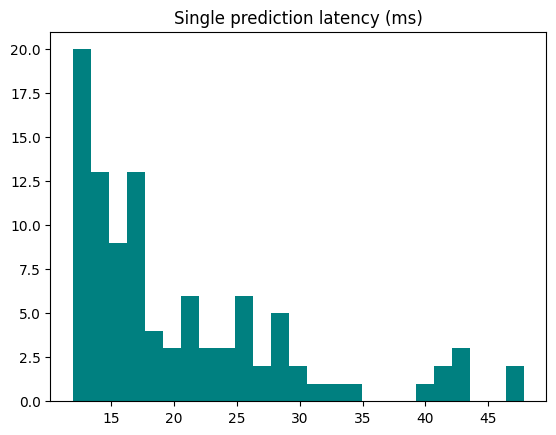

In [7]:
import matplotlib.pyplot as plt

times = []
for i in range(100):
    start = time.time()
    requests.post(base + "/predict", json=risky, headers=headers)
    times.append((time.time() - start) * 1000)

times = np.array(times)
print("Requests:", len(times))
print("p50 latency:", round(np.percentile(times, 50), 1), "ms")
print("p95 latency:", round(np.percentile(times, 95), 1), "ms")
print("max latency:", round(times.max(), 1), "ms")
print("server stats:", requests.get(base + "/stats").json())

batch_rows = [risky] * 500
start = time.time()
requests.post(base + "/predict_batch", json=batch_rows, headers=headers)
print("Batch of 500 took", round((time.time() - start) * 1000), "ms")

plt.hist(times, bins=25, color="teal")
plt.title("Single prediction latency (ms)")
plt.show()

## Step 8: Stop the server and write deployment files

In [8]:
server.terminate()
print("Server stopped")

from importlib.metadata import version
requirements = "".join(p + "==" + version(p) + "\n" for p in ["fastapi", "uvicorn", "pandas", "scikit-learn", "joblib", "pydantic"])
print("requirements.txt (pinned to the versions used here, so the model loads the same way in Docker):")
print(requirements)
open("requirements.txt", "w").write(requirements)

py_version = str(sys.version_info.major) + "." + str(sys.version_info.minor)
dockerfile = """FROM python:PYVER-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py churn_model.joblib model_info.json ./
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""
dockerfile = dockerfile.replace("PYVER", py_version)
open("Dockerfile", "w").write(dockerfile)

print(dockerfile)
print("To run it on your own computer with Docker installed:")
print("  docker build -t churn-api .")
print("  docker run -p 8000:8000 -e API_KEY=choose-a-secret churn-api")
print("  (the Dockerfile was written here but not run inside Colab, so test it once on your own machine)")
print("  then open http://localhost:8000/docs for the automatic API docs page")

Server stopped
requirements.txt (pinned to the versions used here, so the model loads the same way in Docker):
fastapi==0.141.1
uvicorn==0.53.0
pandas==2.2.3
scikit-learn==1.6.1
joblib==1.6.0
pydantic==2.13.5

FROM python:3.13-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py churn_model.joblib model_info.json ./
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

To run it on your own computer with Docker installed:
  docker build -t churn-api .
  docker run -p 8000:8000 -e API_KEY=choose-a-secret churn-api
  (the Dockerfile was written here but not run inside Colab, so test it once on your own machine)
  then open http://localhost:8000/docs for the automatic API docs page


## Step 9: Key insights

In [9]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Model test AUC:", round(auc, 3))
print("2. p50 latency:", round(np.percentile(times, 50), 1), "ms and p95:", round(np.percentile(times, 95), 1), "ms")
print("3. Automated checks passed:", int(test_table["passed"].sum()), "of", len(test_table), "(bad input 422, wrong or missing key 401, oversized batch 413)")
print("4. Files created for deployment: app.py, churn_model.joblib, model_info.json, requirements.txt, Dockerfile")
print("\nNext steps: add logging to a database, add model monitoring (data drift), and deploy on Render, Railway or Cloud Run.")

KEY INSIGHTS (calculated from this run)
1. Model test AUC: 0.84
2. p50 latency: 17.4 ms and p95: 41.4 ms
3. Automated checks passed: 11 of 11 (bad input 422, wrong or missing key 401, oversized batch 413)
4. Files created for deployment: app.py, churn_model.joblib, model_info.json, requirements.txt, Dockerfile

Next steps: add logging to a database, add model monitoring (data drift), and deploy on Render, Railway or Cloud Run.



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)